In [3]:
# data sets
from torch_geometric.datasets import QM9
from tdc.utils import get_reaction_type

# rdkit things
from rdkit import Chem
from rdkit.Chem import GetPeriodicTable
from rdkit.Chem import rdChemReactions
from rdkit.Chem import Draw
from rdkit.Chem.Draw import ReactionToImage
from rdkit.Chem.Draw import MolToImage

# standard libraries
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

First off, I need a DFT dataset to make features for the molecules in the reaction set. A pretty common open-source one is the QM9 dataset. Let's explore what it has to offer. (Later on I will discard and not use this data set in preference for the alchemy data set.)

In [4]:
dataset = QM9(root="Collected Data/QM9")

print(f"Number of molecules: {len(dataset)}")
print(dataset[0])
print("Target vector shape:", dataset[0].y.shape)

# Check the unique elements in the dataset
ptable = GetPeriodicTable()
elements = set()

for data in dataset:
    elements.update(ptable.GetElementSymbol(int(z)) for z in data.z)
print("Elements in QM9:", sorted(elements))

Number of molecules: 130831
Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1])
Target vector shape: torch.Size([1, 19])
Elements in QM9: ['C', 'F', 'H', 'N', 'O']


QM9(130831)

Length of target vector: 19

Atomic numbers (z): tensor([7, 6, 8, 6, 8, 1, 1, 1])
Positions (pos): tensor([[-9.4600e-02,  1.2931e+00,  1.0200e-02],
        [-1.8700e-02,  4.0500e-02,  2.4000e-03],
        [-1.1760e+00, -6.9140e-01,  9.4000e-03],
        [-1.0774e+00, -2.0519e+00,  1.4000e-03],
        [-2.0364e+00, -2.7538e+00,  6.9000e-03],
        [ 8.3740e-01,  1.7042e+00,  3.5000e-03],
        [ 8.8760e-01, -5.7590e-01, -9.8000e-03],
        [-3.1100e-02, -2.4080e+00, -1.0400e-02]])
Targets (y): tensor([[ 4.2338e+00,  3.5690e+01, -7.9838e+00, -8.1090e-01,  7.1729e+00,
          4.6071e+02,  1.5029e+00, -7.7051e+03, -7.7049e+03, -7.7049e+03,
         -7.7058e+03,  1.5704e+01, -3.3994e+01, -3.4164e+01, -3.4344e+01,
         -3.1872e+01,  4.6298e+01,  2.5867e+00,  2.4499e+00]])
SMILES: [H][N-][C+]([H])OC([H])=O


(-0.5, 299.5, 299.5, -0.5)

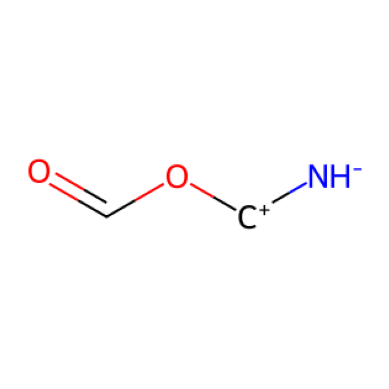

In [5]:
# What are the features that are available in the dataset?
display(dataset)

qm9_targets = [
    "dipole_moment",
    "polarizability",
    "HOMO",
    "LUMO",
    "gap",
    "R2",
    "ZPVE",
    "U0",
    "U",
    "H",
    "G",  
    "Cv",
    "atomization_1",
    "atomization_2",
    "atomization_3",
    "atomization_4",
    "atomization_5",
    "atomization_6",
    "atomization_7"
] # these are the 19 target properties in QM9
print("Length of target vector:", len(qm9_targets))

data = dataset[109]
print("\nAtomic numbers (z):", data.z)
print("Positions (pos):", data.pos)
print("Targets (y):", data.y)
print("SMILES:", data.smiles)

mol = Chem.MolFromSmiles(data.smiles)
img = Draw.MolToImage(mol)
plt.imshow(img)
plt.axis('off')

Next, I want to understand something about how they react so I will use the USPTO-50K dataset derived from the USPTO data which is just a whole bunch of standard organic reactions and some researched ones that work. 

,reactant,product,category
0,C1=COCCC1.COC(=O)CCC(=O)c1ccc(O)cc1O,COC(=O)CCC(=O)c1ccc(OC2CCCCO2)cc1O,1
1,COC(=O)c1cccc(C(=O)O)c1.Nc1cccnc1N,COC(=O)c1cccc(-c2nc3cccnc3[nH]2)c1,4
2,CC(C)(C)OC(=O)NC1CCC(C(=O)O)CC1.CNOC,CON(C)C(=O)C1CCC(NC(=O)OC(C)(C)C)CC1,2
3,Nc1ccc(O)cc1.O=[N+]([O-])c1ccc(Cl)nc1Cl,O=[N+]([O-])c1ccc(Cl)nc1Nc1ccc(O)cc1,1
4,[N-]=[N+]=NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([...,NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([N+](=O)[O-...,9
...,...,...,...
50032,CC(C)(C)OC(=O)N1CCc2cccc3c2[C@H](CN3)C1.OB(O)C...,CC(C)(C)OC(=O)N1CCc2cccc3c2[C@@H](C1)CN3C1CC1,1
50033,CC(=O)Cl.CC(C)(C)OC(=O)NCCO,CC(=O)OCCNC(=O)OC(C)(C)C,2
50034,Cc1ccc(Br)cc1C=O.OB(O)c1ccncc1,Cc1ccc(-c2ccncc2)cc1C=O,3
50035,CC(C)(C)O.O=CC1=C[C@H]2CC(O)O[C@H]2C1,CC(C)(C)OC1C[C@@H]2C=C(C=O)C[C@@H]2O1,1


Category: 1
Reactants: C1=COCCC1.COC(=O)CCC(=O)c1ccc(O)cc1O
Product: COC(=O)CCC(=O)c1ccc(OC2CCCCO2)cc1O


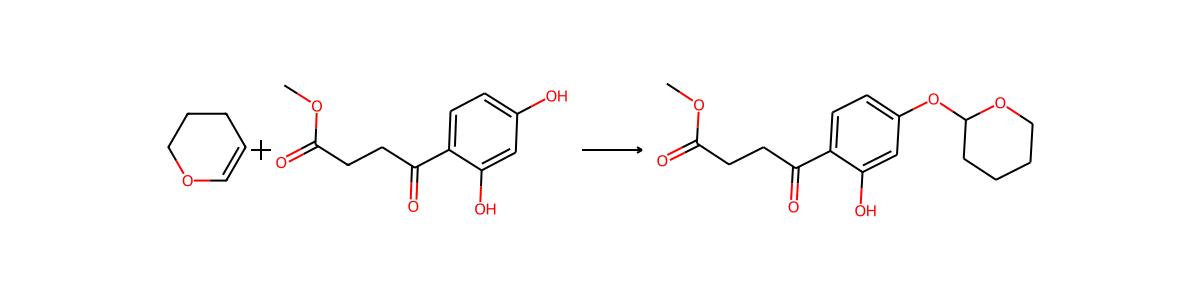

In [6]:
# Reaction Types Exploration
reaction_types_df = get_reaction_type(
    'USPTO-50K',
    path='Collected Data/',
    output_format='df'
)
display(reaction_types_df)

reaction_map = {
    1: "Heteroatom alkylation and arylation",
    2: "Acylation and related processes",
    3: "C–C bond formation",
    4: "Heterocycle formation",
    5: "Protections",
    6: "Deprotections",
    7: "Reductions",
    8: "Oxidations",
    9: "Functional group interconversion (FGI)",
    10: "Functional group addition (FGA)"
} # reactants and products are seperated with periods "."

# pick any reaction to visualize
row = reaction_types_df.iloc[0] 
print("Category:", row["category"])
print("Reactants:", row["reactant"])
print("Product:", row["product"])

rxn_smiles = f"{row['reactant']}>>{row['product']}"
rxn = rdChemReactions.ReactionFromSmarts(rxn_smiles, useSmiles=True)

img = ReactionToImage(rxn, subImgSize=(300, 300))
display(img)

In [7]:
# Find the unique elements in the reactants and products of the reaction types
def get_unique_elements_clean(df):
    element_counts = {}
    cache = {}

    for row in df.itertuples(index=False):
        smiles_list = (row.reactant + "." + row.product).split(".")

        for smi in smiles_list:
            # cache parsed elements
            if smi not in cache: 
                # shove it into the cache
                mol = Chem.MolFromSmiles(smi)
                if mol is None:
                    cache[smi] = []
                else:
                    cache[smi] = [atom.GetSymbol() for atom in mol.GetAtoms()]

            # update counts
            for elem in cache[smi]:
                # just to see what elements and reactions are most present in the dataset
                if elem in element_counts:
                    element_counts[elem] += 1
                else:
                    element_counts[elem] = 1

    unique_elements = sorted(element_counts.keys())

    return unique_elements, element_counts


unique_elements, element_counts = get_unique_elements_clean(reaction_types_df)

print("Unique elements:")
print(unique_elements)

print("\nElement counts:")
for k, v in element_counts.items():
    print(f"{k}: {v}")

Unique elements:
['B', 'Br', 'C', 'Cl', 'Cu', 'F', 'Fe', 'I', 'K', 'Li', 'Mg', 'N', 'O', 'P', 'Pb', 'Pd', 'Pt', 'S', 'Se', 'Si', 'Sn', 'Zn']

Element counts:
C: 1978431
O: 310243
N: 269166
Cl: 37292
F: 63892
S: 28877
Si: 2287
I: 3201
Br: 15135
Sn: 322
Li: 21
Mg: 294
B: 3362
P: 683
Se: 22
Zn: 67
Cu: 64
Pb: 1
K: 2
Pt: 2
Fe: 1
Pd: 1


So either we need cut the reactions with elements the QM9 dataset does not have, find a DFT dataset that has more elements, or both. 
I can eliminate the reactions and elements that have 'low' element counts as they will not be helpful in training, validating, and testing. 
Then I need to go online and find a QM9-like dataset that has more (doesn't necessarily need to be all) of these elements. 
Even though I could just do CHONF, out of personal preference I wanna try to add *some* interesting elements; CHONF by itself sounds a bit stale. 

In [8]:
new_element_counts = {elem: count for elem, count in element_counts.items() if count > 100}  
print("\nElements with more than 100 occurrences:")
for k, v in new_element_counts.items():
    print(f"{k}: {v}")


Elements with more than 100 occurrences:
C: 1978431
O: 310243
N: 269166
Cl: 37292
F: 63892
S: 28877
Si: 2287
I: 3201
Br: 15135
Sn: 322
Mg: 294
B: 3362
P: 683


The alchemy dataset is was made as some competition between chemists in 2019. They claim to have a 200k data set with CHONF + S and Cl. To bad it doesn't have Br but we'll have to live with that. Now, let's see what the alchemy dataset looks like. 

File: Collected Data/Alchemy-v20191129/atom_9/2536808.sdf

SMILES: C[C@]1([NH3+])CC=CCCC1

Properties:

Property values:

Atoms: ['C', 'C', 'N', 'C', 'C', 'C', 'C', 'C', 'C']


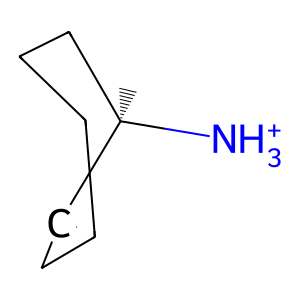

In [9]:
# The CSV file does not have a column for the smiles but rather just the ID of the molecule corresponding to a sdf file in an atom file. 
# An atom_9 file has molecules with 9 atoms, atom_10 has molecules with 10 atoms, and so on.

# Before we do that though, let us visualize a molecule from the dataset and see what it looks like

# get one sdf file automatically
# glob is a library for finding files matching a specified pattern
files = glob.glob("Collected Data/Alchemy-v20191129/atom_9/*.sdf")
file = files[0]

print("File:", file)

# load molecule
supplier = Chem.SDMolSupplier(file)

# make sure this molecule object exists in the first place
mol = None
for m in supplier: # possibly multiple molecules in one sdf file, but likely there's only one
    if m is not None:
        mol = m
        break

if mol is None:
    print("No valid molecule found.")
else:
    # SMILES
    print("\nSMILES:", Chem.MolToSmiles(mol))

    # properties
    print("\nProperties:")
    props = mol.GetPropNames()
    print(props)

    print("\nProperty values:")
    for p in props:
        print(f"{p}: {mol.GetProp(p)}")

    # atoms
    atoms = [atom.GetSymbol() for atom in mol.GetAtoms()]
    print("\nAtoms:", atoms)

    # visualize
    display(MolToImage(mol))

In [10]:
base = "Collected Data/Alchemy-v20191129"

# load original CSV
df = pd.read_csv(f"{base}/final_version.csv")

smiles_data = []

# loop through all atom folders
for folder in ["atom_9", "atom_10", "atom_11", "atom_12"]:
    files = glob.glob(f"{base}/{folder}/*.sdf") 
    
    for file in files:
        supplier = Chem.SDMolSupplier(file)
        
        mol = None # again, make sure this molecule object exists
        for m in supplier:
            if m is not None:
                mol = m
                break
        
        if mol is None:
            continue
        
        # extract index from filename
        name = os.path.basename(file)
        gdb_idx = int(name.split(".")[0].split("_")[-1])
        
        # get SMILES
        smiles = Chem.MolToSmiles(mol)
        
        smiles_data.append([gdb_idx, smiles])

# build dataframe
smiles_df = pd.DataFrame(smiles_data, columns=["gdb_idx", "smiles"])

# merge with original CSV using the gdb_idx to correlate
merged = df.merge(smiles_df, on="gdb_idx", how="left")

# save new CSV
merged.to_csv(f"{base}/final_version_with_smiles.csv", index=False)

# quick check
print(merged[["gdb_idx", "smiles"]].head())
print("Matched:", merged["smiles"].notna().mean()*100, "%") # everything has a smiles!

   gdb_idx                         smiles
0  2859833               CC#CC[C@H](C)CCC
1  3148292         C#CC[C@@H]1CO[C@@H]1CC
2  3607838       CC[C@H]1[C@H]2CCO[C@]21C
3  9540153                COc1nccc2c1OCC2
4   340363  CC1=CC[C@H]2C[C@@H]2[C@H]1C#N
Matched: 100.0 %


In [11]:
df = pd.read_csv("Collected Data/Alchemy-v20191129/final_version_with_smiles.csv")

elements = set()

for smi in df["smiles"]:
    mol = Chem.MolFromSmiles(smi)
    for atom in mol.GetAtoms():
        elements.add(atom.GetSymbol())

print("Elements in dataset:", sorted(elements))

Elements in dataset: ['C', 'Cl', 'F', 'H', 'N', 'O', 'S']


Okay, now that I have the elements I can work with from alchemy data (200k examples), how much of the UPTSO-50K data do I have left to work with?

In [12]:
alchemy_elements = elements # just to make it a set for faster lookup

def get_elements_from_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return {atom.GetSymbol() for atom in mol.GetAtoms()}

def reaction_is_alchemy_compatible(row):
    smiles_list = (row["reactant"] + "." + row["product"]).split(".")
    for smi in smiles_list:
        elems = get_elements_from_smiles(smi)
        if elems is None:
            return False
        if not elems.issubset(alchemy_elements):
            return False
    return True

mask = reaction_types_df.apply(reaction_is_alchemy_compatible, axis=1)

usable_df = reaction_types_df[mask].copy()
removed_df = reaction_types_df[~mask].copy()

print("Total reactions:", len(reaction_types_df))
print("Usable with Alchemy:", len(usable_df))
print("Removed:", len(removed_df))
print("Percent usable:", 100 * len(usable_df) / len(reaction_types_df))
# thats's still a good amount of reactions we can work with

Total reactions: 50037
Usable with Alchemy: 35116
Removed: 14921
Percent usable: 70.18006675060455


Now that we have the two dataset and have made sure they are compatible with eachother; here I will do the last touches to get the data frames ready for ML. I am going to make a seperate ipynb now where I will load just this data to be used because the prospect of reloading this ipynb that take three minutes everytime I want to run all is not practical.

In [ ]:
# Make a data frame with all the reaction types that have elements from the alchemy dataset.
# This naming convention for the dataframes will be used in the next ipynb file. 

alchemy_elements = alchemy_elements # set class
reaction_types_df = usable_df.copy() # reassign
usable_df.to_csv("Collected Data/uspto_50k_processed.csv", index=False) # shove into a csv for use in a different notebook
print("USTPO-50K reactions:", reaction_types_df.shape[0])

molecule_types_df = pd.read_csv("Collected Data/Alchemy-v20191129/final_version_with_smiles.csv")
print("Alchemy molecules:", molecule_types_df.shape[0])

USTPO-50K reactions: 35116
Alchemy molecules: 202579
